# Exercises XP - Heart Disease Prediction (Student, Hints Only)

## What you will learn
- Load and inspect CSV data
- EDA and preprocessing
- Train Logistic Regression, SVM, XGBoost
- Hyperparameter tuning with GridSearchCV
- Evaluate with standard metrics

## What you will create
- Working classifiers and a simple comparison report


## Setup

In [2]:
import os, zipfile, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Hint: install xgboost in Colab if missing
# !pip install xgboost
try:
    from xgboost import XGBClassifier
except Exception:
    XGBClassifier = None

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## Exercise 1 - Exploratory Data Analysis

In [ ]:
# TODO: extract the dataset zip to an output folder
ZIP_PATH = 'Heart Disease Prediction Dataset.zip'  # or your path
EXTRACT_DIR = 'heart_ds'
# Hint: use zipfile.ZipFile(ZIP_PATH).extractall(EXTRACT_DIR)

# TODO: list CSV files under EXTRACT_DIR
with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref :
    zip_ref.extractall(EXTRACT_DIR)

csv_path = 'heart_ds/dataset_heart.csv' # set to the CSV you choose

# TODO: load the CSV into a DataFrame named df
df =pd.read_csv(csv_path)

# TODO: inspect df
print(f'''first 5 rows: 
{df.head()}''')
print('')
print(f''' data info :
{df.info()}''')
print()
print(f'''data statistics : 
{df.describe()}''')
print()
print(f'data shape: {df.columns.tolist()}')

# # TODO: identify target column
target = df['heart disease']  # 'target'

 # TODO: split features and target
X = df.drop(columns='heart disease') 
y = df['heart disease'] 

 # TODO: train test split with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                    random_state=RANDOM_STATE, stratify=y)

 # Hint: train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)


first 5 rows: 
   age  sex   chest pain type  resting blood pressure  serum cholestoral  \
0   70     1                4                     130                322   
1   67     0                3                     115                564   
2   57     1                2                     124                261   
3   64     1                4                     128                263   
4   74     0                2                     120                269   

   fasting blood sugar  resting electrocardiographic results  max heart rate  \
0                    0                                     2             109   
1                    0                                     2             160   
2                    0                                     0             141   
3                    0                                     0             105   
4                    0                                     2             121   

   exercise induced angina  oldpeak  ST segment

### Basic visual checks

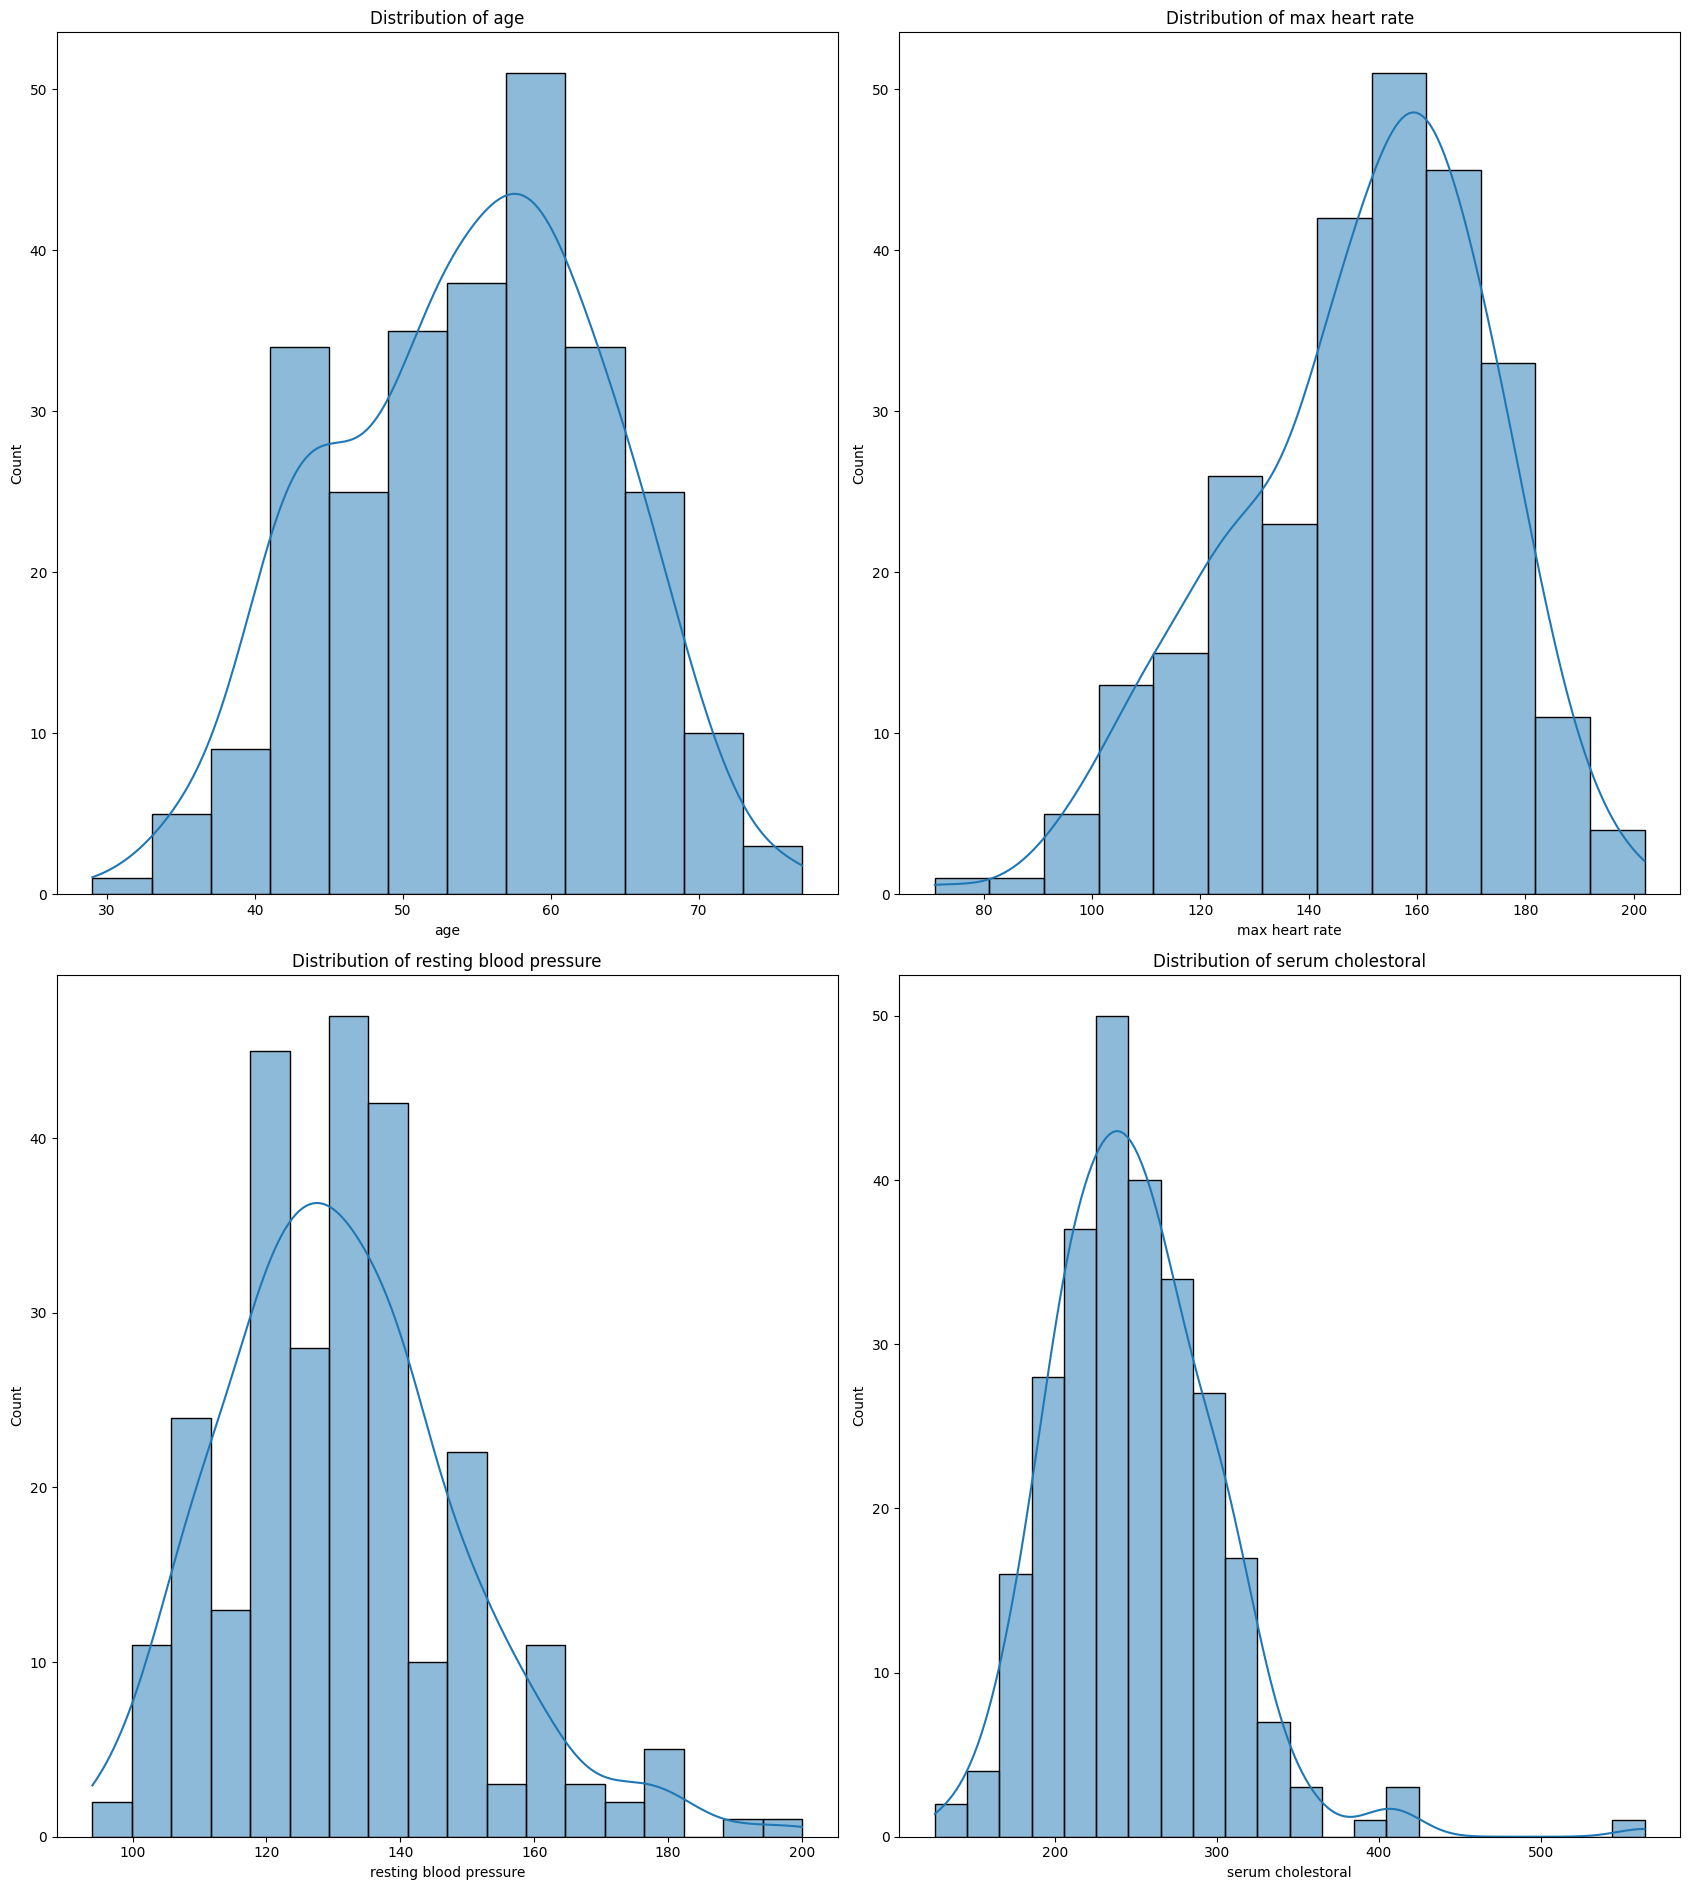

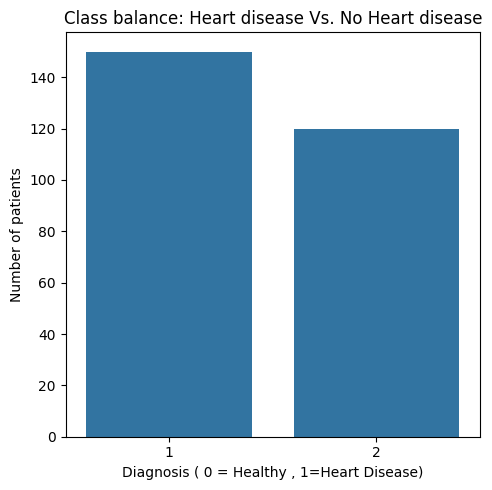

In [36]:
# TODO: pick a few numeric columns and plot histograms
import seaborn as sns
cols = ['age','max heart rate','resting blood pressure','serum cholestoral']
# TODO: pick a few numeric columns and plot histograms
import matplotlib.pyplot as plt

cols = ['age','max heart rate','resting blood pressure','serum cholestoral']
fig, axes = plt.subplots(2, 2, figsize=(17, 19))

for ax, col in zip(axes.flatten(), cols):
    sns.histplot(data=df, x=col, ax=ax, kde=True)
    ax.set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

# TODO: plot class balance as a bar chart
plt.figure(figsize=(5, 5))
sns.countplot(data=df, x='heart disease')
plt.title('Class balance: Heart disease Vs. No Heart disease')
plt.xlabel('Diagnosis ( 0 = Healthy , 1=Heart Disease)')
plt.ylabel('Number of patients')
plt.tight_layout()
plt.show()





## Preprocessing pipeline

In [43]:
num_cols = X.select_dtypes(include = ['number']).columns.tolist()  # list of object, category, or bool columns
cat_cols = X.select_dtypes(include =['object', 'category']).columns.tolist()  # list of numeric columns
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# TODO: build a ColumnTransformer named pre
pre = ColumnTransformer(transformers=[('num', StandardScaler(), num_cols), 
                                      ('cat', OneHotEncoder(), cat_cols)])



## Helper - evaluation function

In [68]:
def eval_and_report(name, model, X_test, y_test, y_prob=None):
    """Compute metrics and draw confusion matrix and ROC if available.
    Fill in the missing parts.
    """
    # TODO: predictions
    y_pred = model.predict(X_test)
    # TODO: compute metrics dict with accuracy, precision, recall, f1
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred)
    }
    print(name, metrics)
    # TODO: confusion matrix plot
    # Hint: confusion_matrix(y_test, y_pred)
    # Draw with plt.imshow or ConfusionMatrixDisplay
    
    cm = confusion_matrix(y_test, y_pred)
    plt.imshow(cm)
    plt.title('Confusion Matrix')
    plt.show()
    # TODO: confusion matrix plot
    # Hint: confusion_matrix(y_test, y_pred)
    # Draw with plt.imshow or ConfusionMatrixDisplay
    
    # TODO: ROC curve if model has predict_proba
    if y_prob is not None:
        if y_prob.ndim == 2:
            y_score = y_prob[:, 1]  # probability for the positive class
        else:
            y_score = y_prob
        fpr, tpr, _ = roc_curve(y_test, y_score, pos_label=2)
        auc_score = roc_auc_score(y_test, y_score)
        plt.plot(fpr, tpr, label=f'Auc ={auc_score:.2f}', color='darkorange')
        plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
        plt.legend(loc='lower right')
        plt.title('ROC Curve')
        plt.show()

    return metrics

## Exercise 2 - Logistic Regression without Grid Search

Logistic pipeline {'accuracy': 0.8518518518518519, 'precision': 0.9230769230769231, 'recall': 0.8, 'f1': 0.8571428571428571}


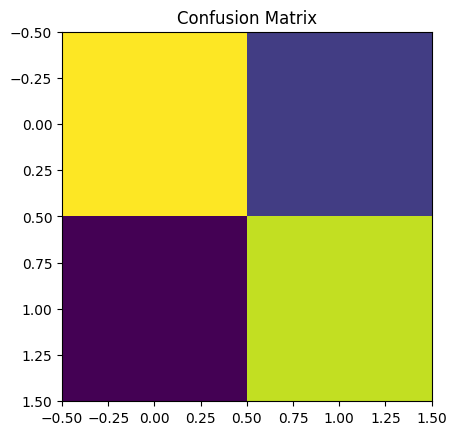

In [44]:
# TODO: create a Pipeline with your preprocessor and LogisticRegression
# Hint: solver 'liblinear' is fine, increase max_iter if needed
pipe_lr = Pipeline([('preprocessing', pre),('clasifier', LogisticRegression(solver='liblinear', max_iter =1000))])

# TODO: fit on training data
# pipe_lr.fit(...)
pipe_lr.fit(X_train, y_train)

# TODO: evaluate with eval_and_report
lr_no_gs_metrics = eval_and_report('Logistic pipeline',pipe_lr, X_test,y_test)




## Exercise 3 - Logistic Regression with Grid Search

Best params: {'classifier__C': 0.01, 'classifier__penalty': 'l2', 'classifier__solver': 'saga'}
LR grid {'accuracy': 0.8518518518518519, 'precision': 0.8666666666666667, 'recall': 0.8666666666666667, 'f1': 0.8666666666666667}


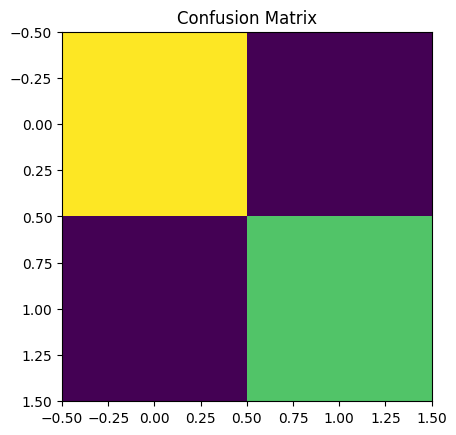

In [48]:
from sklearn.model_selection import train_test_split, GridSearchCV
# TODO: build a Pipeline same as above
pipe_lr_cv = Pipeline([('preprocessing',pre),('classifier', LogisticRegression(solver = 'liblinear'))])

# TODO: define param_grid for lr__C and lr__penalty
# Hint: use small to large C values. 'liblinear' supports 'l1' and 'l2'.
param_grid = {
    'classifier__C': [0.01,0.1,1],
    'classifier__penalty': ['l1','l2'],
    'classifier__solver' :['liblinear','saga']
    }

# TODO: GridSearchCV with cv=5 and scoring='f1'
grid_lr =GridSearchCV(estimator =pipe_lr_cv, param_grid= param_grid,cv=5,scoring= 'f1', n_jobs =-1)
grid_lr.fit(X_train,y_train)
# grid_lr.fit(...)
print('Best params:', grid_lr.best_params_)
best_lr = grid_lr.best_estimator_
lr_gs_metrics = eval_and_report('LR grid', best_lr, X_test, y_test)


## Exercise 4 - SVM without Grid Search

SVM no grid {'accuracy': 0.8148148148148148, 'precision': 0.8571428571428571, 'recall': 0.8, 'f1': 0.8275862068965517}


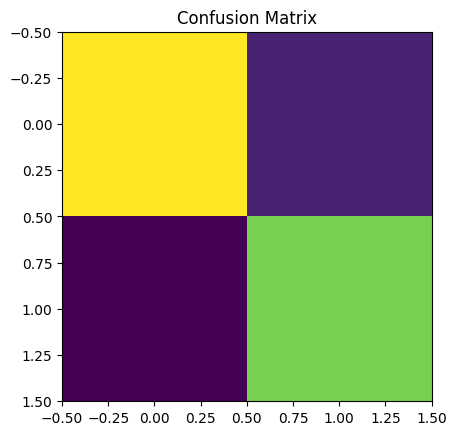

In [52]:
# TODO: choose kernel and hyperparameters for SVC
# Hint: try kernel='rbf' with C=1.0 and gamma='scale'
pipe_svm = Pipeline([('preprocessing',pre),('clasifier', 
SVC(kernel ='rbf', C=1, gamma='scale', probability = True))])
pipe_svm.fit(X_train, y_train)
svm_no_metrics = eval_and_report('SVM no grid', pipe_svm, X_test, y_test)


## Exercise 5 - SVM with Grid Search

SVM grid {'accuracy': 0.8518518518518519, 'precision': 0.8928571428571429, 'recall': 0.8333333333333334, 'f1': 0.8620689655172413}


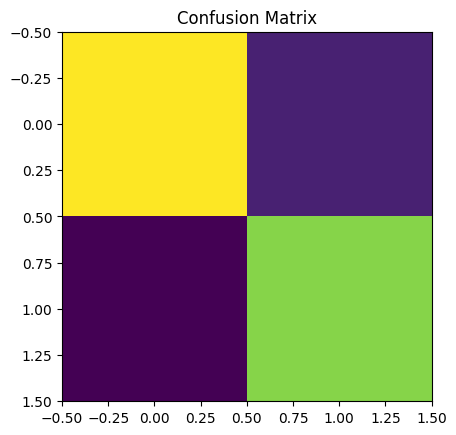

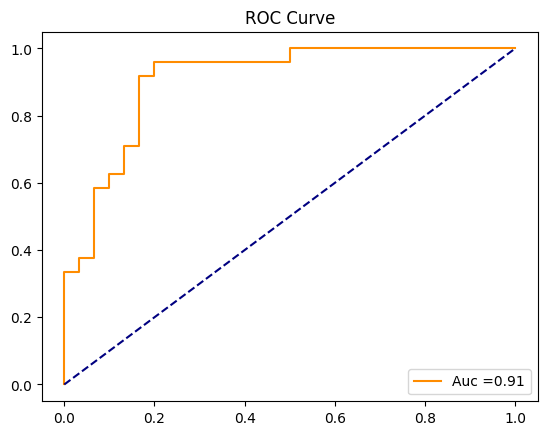

In [66]:
# TODO: Pipeline with SVC(probability=True) so you can plot ROC
pipe_svm_cv =Pipeline([('preprocessing',pre),('classifier', 
SVC(kernel ='rbf', C=1, gamma='scale', probability = True))])

# TODO: param_grid with svm__kernel, svm__C, svm__gamma
svm_param_grid = {
    'classifier__kernel': ['rbf','linear'],
    'classifier__C': [0.1,1,10],
    'classifier__gamma': ['scale','auto']
}

# TODO: GridSearchCV, fit, evaluate best estimator
grid_svm = GridSearchCV(pipe_svm_cv, svm_param_grid, cv =5 ,scoring ='accuracy', n_jobs =-1)
grid_svm.fit(X_train,y_train) 
best_svm = grid_svm.best_estimator_
y_prob =best_svm.predict_proba(X_test)
svm_gs_metrics = eval_and_report('SVM grid', best_svm, X_test, y_test, y_prob)



## Exercise 6 - XGBoost without Grid Search

XGB no grid {'accuracy': 0.8333333333333334, 'precision': 0.8, 'recall': 0.8333333333333334, 'f1': 0.8163265306122449}


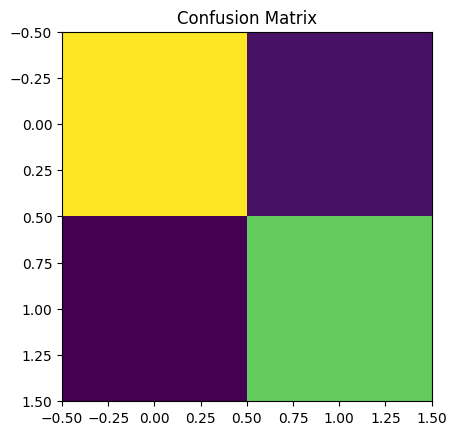

In [75]:
# TODO: build an XGBClassifier and wrap it in a Pipeline with pre
# Hint: start with n_estimators around 300, learning_rate 0.1, max_depth 3 to 5
pipe_xgb = Pipeline([('preprocessing', pre),('classifier', XGBClassifier( n_estimators =300, learning_rate =0.1, max_depth =4))])

# Ensure binary labels exist (original target uses 1/2)
y_train_bin = (y_train == 2).astype(int)
y_test_bin = (y_test == 2).astype(int)

pipe_xgb.fit(X_train, y_train_bin)
xgb_no_metrics = eval_and_report('XGB no grid', pipe_xgb, X_test, y_test_bin)



## Exercise 7 - XGBoost with Grid Search

XGB grid {'accuracy': 0.8148148148148148, 'precision': 0.7692307692307693, 'recall': 0.8333333333333334, 'f1': 0.8}


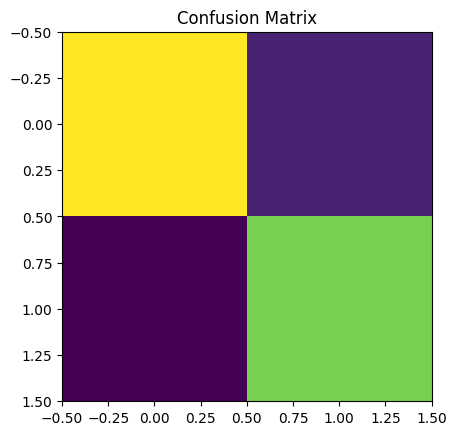

In [79]:
# TODO: Pipeline with XGBClassifier
pipe_xgb_cv = Pipeline([('preprocessing', pre),('classifier', XGBClassifier( n_estimators =300, learning_rate =0.1, max_depth =4))])

# TODO: define a reasonable param_grid
xgb_param_grid = {
    'classifier__n_estimators': [50, 100, 150],
    'classifier__learning_rate': [0.01, 0.1, 0.4],
    'classifier__max_depth': [3, 5, 7],
    'classifier__subsample': [0.8, 1.0],
    'classifier__colsample_bytree': [0.7, 0.9, 1.0]
}

# TODO: GridSearchCV, fit, evaluate best estimator
grid_xgb = GridSearchCV(estimator=pipe_xgb_cv, param_grid=xgb_param_grid, cv=5, scoring='f1', n_jobs=-1)
y_train_bin = (y_train == 2).astype(int)
y_test_bin = (y_test == 2).astype(int)

grid_xgb.fit(X_train, y_train_bin)

best_xgb = grid_xgb.best_estimator_
xgb_gs_metrics = eval_and_report('XGB grid', best_xgb, X_test, y_test_bin)



## Compare models

lr_no_gs_metrics,lr_gs_metrics,svm_no_metrics, svm_gs_metrics,xgb_no_metrics,xgb_gs_metrics

In [ ]:
# TODO: build a comparison DataFrame from your metrics dicts
# Hint: pd.DataFrame.from_dict(metrics, orient='index')
summary ={'LogisticRegression':lr_no_gs_metrics, 'LR grid' :lr_gs_metrics, 'SVM':svm_no_metrics, 'SVM_grid':svm_gs_metrics, 'xgbclassifier':xgb_no_metrics, 'xgb_grid':xgb_gs_metrics}
metrics_compared = pd.DataFrame.from_dict(summary, orient='index')

# summary['LR no grid'] = lr_no_gs_metrics
# ... add others you computed ...
summary


{'LogisticRegression': {'accuracy': 0.8518518518518519,
  'precision': 0.9230769230769231,
  'recall': 0.8,
  'f1': 0.8571428571428571},
 'LR_grid': {'accuracy': 0.8518518518518519,
  'precision': 0.8666666666666667,
  'recall': 0.8666666666666667,
  'f1': 0.8666666666666667},
 'SVM': {'accuracy': 0.8148148148148148,
  'precision': 0.8571428571428571,
  'recall': 0.8,
  'f1': 0.8275862068965517},
 'SVM_grid': {'accuracy': 0.8518518518518519,
  'precision': 0.8928571428571429,
  'recall': 0.8333333333333334,
  'f1': 0.8620689655172413},
 'xgbclassifier': {'accuracy': 0.8333333333333334,
  'precision': 0.8,
  'recall': 0.8333333333333334,
  'f1': 0.8163265306122449},
 'xgb_grid': {'accuracy': 0.8148148148148148,
  'precision': 0.7692307692307693,
  'recall': 0.8333333333333334,
  'f1': 0.8}}